In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
WORKING_DIR = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/7_HIPHOP_validation/Dose-dependent"
)

INPUT_DIR = WORKING_DIR / "inputs"
INPUT_FILE = INPUT_DIR / "PILOT_17H.xlsx"

OUTPUT_DIR = WORKING_DIR / "PILOT_17H_outputs"
OD_OUTDIR = OUTPUT_DIR / "OD600_figures"
FD_OUTDIR = OUTPUT_DIR / "FD_figures"
SUMMARY_OUTDIR = OUTPUT_DIR / "summary_tables"

for folder in [OD_OUTDIR, FD_OUTDIR, SUMMARY_OUTDIR]:
    folder.mkdir(parents=True, exist_ok=True)

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"File not found: {INPUT_FILE}")

CONCENTRATION_ORDER = [0, 0.25, 0.5, 1, 2, 4, 8, 16]

STRAIN_ORDER = ["PDR1", "ERG11", "RM", "BY"]

DISPLAY_LABELS = {
    "PDR1": r"$\Delta\it{PDR1}$",
    "ERG11": r"$\Delta\it{ERG11}$",
    "RM": "RM",
    "BY": "BY",
}

STRAIN_COLORS = {
    "PDR1": "#4C78A8",
    "ERG11": "#F58518",
    "RM": "#A6A6A6",
    "BY": "#3A3A3A",
}

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_DIR)

Input: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/inputs/PILOT_17H.xlsx
Output: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/PILOT_17H_outputs


In [3]:
COLUMN_PATTERN = re.compile(
    r"^(.*?)\s+Rep(\d+)$",
    re.IGNORECASE
)

CONCENTRATION_PATTERN = re.compile(
    r"^([0-9]*\.?[0-9]+)\s*[x×]\s*MIC$",
    re.IGNORECASE
)


def read_and_reshape(file_path):
    wide = pd.read_excel(file_path)

    wide = wide.rename(
        columns={wide.columns[0]: "Concentration_label"}
    )

    labels = (
        wide["Concentration_label"]
        .astype(str)
        .str.strip()
    )

    extracted = labels.str.extract(
        CONCENTRATION_PATTERN,
        expand=False
    )

    if extracted.isna().any():
        raise ValueError("Could not parse concentration labels.")

    wide["Concentration"] = extracted.astype(float)

    long_parts = []

    for column in wide.columns:
        if column in {"Concentration_label", "Concentration"}:
            continue

        match = COLUMN_PATTERN.fullmatch(str(column).strip())

        if match is None:
            raise ValueError(
                f"Could not interpret column: {column}"
            )

        part = wide[["Concentration", column]].copy()
        part = part.rename(columns={column: "OD600"})

        part["Strain"] = match.group(1).strip()
        part["Replicate"] = int(match.group(2))

        long_parts.append(part)

    long_df = pd.concat(long_parts, ignore_index=True)

    long_df["OD600"] = pd.to_numeric(
        long_df["OD600"],
        errors="coerce"
    )

    if long_df["OD600"].isna().any():
        raise ValueError("Missing or nonnumeric OD600 values found.")

    if set(long_df["Concentration"]) != set(CONCENTRATION_ORDER):
        raise ValueError("Unexpected concentration set found.")

    if set(long_df["Strain"]) != set(STRAIN_ORDER):
        raise ValueError("Unexpected strain set found.")

    if set(long_df["Replicate"]) != {1, 2, 3}:
        raise ValueError("Expected Rep1, Rep2, and Rep3.")

    long_df["Concentration"] = pd.Categorical(
        long_df["Concentration"],
        categories=CONCENTRATION_ORDER,
        ordered=True
    )

    return (
        long_df
        .sort_values(["Concentration", "Strain", "Replicate"])
        .reset_index(drop=True)
    )


data = read_and_reshape(INPUT_FILE)

print(data.shape)
display(data.head())

(96, 4)


,Concentration,OD600,Strain,Replicate
0,0.0,1.190,BY,1
1,0.0,1.176,BY,2
2,0.0,0.966,BY,3
3,0.0,1.022,ERG11,1
4,0.0,1.037,ERG11,2


In [4]:
def calculate_fitness_defect(long_df):
    df = long_df.copy()

    baseline = (
        df.loc[
            df["Concentration"] == 0,
            ["Strain", "Replicate", "OD600"]
        ]
        .rename(columns={"OD600": "OD600_0x"})
    )

    if baseline.duplicated(
        ["Strain", "Replicate"],
        keep=False
    ).any():
        raise ValueError("Duplicate untreated baselines found.")

    df = df.merge(
        baseline,
        on=["Strain", "Replicate"],
        how="left",
        validate="many_to_one"
    )

    if df["OD600_0x"].isna().any():
        raise ValueError("A matching 0× MIC baseline is missing.")

    if (df[["OD600", "OD600_0x"]] <= 0).any().any():
        raise ValueError("All OD600 values must be greater than zero.")

    df["FD"] = np.log2(
        df["OD600"] / df["OD600_0x"]
    )

    untreated_fd = df.loc[
        df["Concentration"] == 0,
        "FD"
    ]

    if not np.allclose(untreated_fd, 0):
        raise ValueError("Untreated FD values are not zero.")

    return df


data_with_fd = calculate_fitness_defect(data)

print(data_with_fd.shape)
display(data_with_fd.head())

(96, 6)


,Concentration,OD600,Strain,Replicate,OD600_0x,FD
0,0.0,1.190,BY,1,1.190,0.0
1,0.0,1.176,BY,2,1.176,0.0
2,0.0,0.966,BY,3,0.966,0.0
3,0.0,1.022,ERG11,1,1.022,0.0
4,0.0,1.037,ERG11,2,1.037,0.0


In [5]:
def summarize_metric(long_df, metric):
    summary = (
        long_df
        .groupby(
            ["Concentration", "Strain"],
            observed=True,
            sort=False
        )[metric]
        .agg(
            n="count",
            mean="mean",
            sd="std"
        )
        .reset_index()
    )

    summary["SE"] = (
        summary["sd"] / np.sqrt(summary["n"])
    )

    if not (summary["n"] == 3).all():
        raise ValueError(
            f"Every {metric} group must contain 3 replicates."
        )

    return summary


OD_SUMMARY = summarize_metric(data_with_fd, "OD600")
FD_SUMMARY = summarize_metric(data_with_fd, "FD")

OD_SUMMARY.to_csv(
    SUMMARY_OUTDIR / "PILOT_17H_OD600_mean_SE.csv",
    index=False
)

FD_SUMMARY.to_csv(
    SUMMARY_OUTDIR / "PILOT_17H_FD_mean_SE.csv",
    index=False
)

display(OD_SUMMARY.head())
display(FD_SUMMARY.head())

,Concentration,Strain,n,mean,sd,SE
0,0.00,BY,3,1.110667,0.125480,0.072446
1,0.00,ERG11,3,0.979667,0.086639,0.050021
2,0.00,PDR1,3,0.941333,0.102569,0.059218
3,0.00,RM,3,1.186000,0.034220,0.019757
4,0.25,BY,3,0.956333,0.133661,0.077169


,Concentration,Strain,n,mean,sd,SE
0,0.00,BY,3,0.000000,0.000000,0.000000
1,0.00,ERG11,3,0.000000,0.000000,0.000000
2,0.00,PDR1,3,0.000000,0.000000,0.000000
3,0.00,RM,3,0.000000,0.000000,0.000000
4,0.25,BY,3,-0.218731,0.102121,0.058959


In [6]:
def plot_od600_strainwise(summary_df, output_dir):
    """Four subplots, one per strain; bars are concentrations."""

    n_strains = len(STRAIN_ORDER)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_strains,
        figsize=(4.5 * n_strains, 5.5),
        sharey=True,
        squeeze=False
    )

    axes = axes.ravel()

    x = np.arange(len(CONCENTRATION_ORDER))
    concentration_labels = [
        f"{dose:g}× MIC"
        for dose in CONCENTRATION_ORDER
    ]

    for ax, strain in zip(axes, STRAIN_ORDER):
        panel = (
            summary_df.loc[
                summary_df["Strain"] == strain
            ]
            .set_index("Concentration")
            .reindex(CONCENTRATION_ORDER)
        )

        if panel["mean"].isna().any():
            raise ValueError(
                f"Missing OD600 values for {strain}."
            )

        ax.bar(
            x,
            panel["mean"],
            yerr=panel["SE"],
            capsize=4,
            color=STRAIN_COLORS[strain],
            edgecolor="black",
            linewidth=0.8,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2
            }
        )

        ax.set_title(DISPLAY_LABELS[strain])
        ax.set_xticks(x)
        ax.set_xticklabels(
            concentration_labels,
            rotation=45,
            ha="right"
        )
        ax.set_xlabel("Concentration")
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

    fig.text(
        0.01,
        0.5,
        "Final OD600 (mean ± SE, n = 3)",
        va="center",
        rotation="vertical"
    )

    fig.suptitle(
        "PILOT 17 h: OD600",
        fontsize=17,
        fontweight="bold"
    )

    fig.tight_layout(rect=[0.04, 0.02, 1, 0.95])

    png_path = output_dir / "PILOT_17H_OD600_strainwise_1x4.png"
    pdf_path = output_dir / "PILOT_17H_OD600_strainwise_1x4.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return png_path, pdf_path


def plot_fd_dosewise(
    summary_df,
    doses,
    output_dir,
    ncols=4
):
    """Previous layout: one subplot per dose; bars are strains."""

    n_panels = len(doses)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.1 * ncols, 5.0 * nrows),
        sharey=True,
        squeeze=False
    )

    axes = axes.ravel()
    x = np.arange(len(STRAIN_ORDER))

    labels = [
        DISPLAY_LABELS[strain]
        for strain in STRAIN_ORDER
    ]

    colors = [
        STRAIN_COLORS[strain]
        for strain in STRAIN_ORDER
    ]

    for ax, dose in zip(axes, doses):
        panel = (
            summary_df.loc[
                summary_df["Concentration"] == dose
            ]
            .set_index("Strain")
            .reindex(STRAIN_ORDER)
        )

        if panel["mean"].isna().any():
            raise ValueError(
                f"Missing FD values at {dose}× MIC."
            )

        ax.bar(
            x,
            panel["mean"],
            yerr=panel["SE"],
            capsize=4,
            color=colors,
            edgecolor="black",
            linewidth=0.8,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2
            }
        )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1.1,
            alpha=0.7
        )

        ax.set_title(f"{dose:g}× MIC")
        ax.set_xticks(x)
        ax.set_xticklabels(
            labels,
            rotation=45,
            ha="right"
        )
        ax.set_xlabel("Strain")
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

    for ax in axes[n_panels:]:
        ax.remove()

    fig.text(
        0.01,
        0.5,
        (
            r"Fitness defect, "
            r"$\log_2(\mathrm{OD}_{treatment}/"
            r"\mathrm{OD}_{0\times})$"
            "\n(mean ± SE, n = 3)"
        ),
        va="center",
        rotation="vertical"
    )

    fig.suptitle(
        "PILOT 17 h: Fitness defect",
        fontsize=17,
        fontweight="bold"
    )

    fig.tight_layout(rect=[0.04, 0.02, 1, 0.95])

    png_path = output_dir / "PILOT_17H_Fitness_defect_2x4.png"
    pdf_path = output_dir / "PILOT_17H_Fitness_defect_2x4.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return png_path, pdf_path

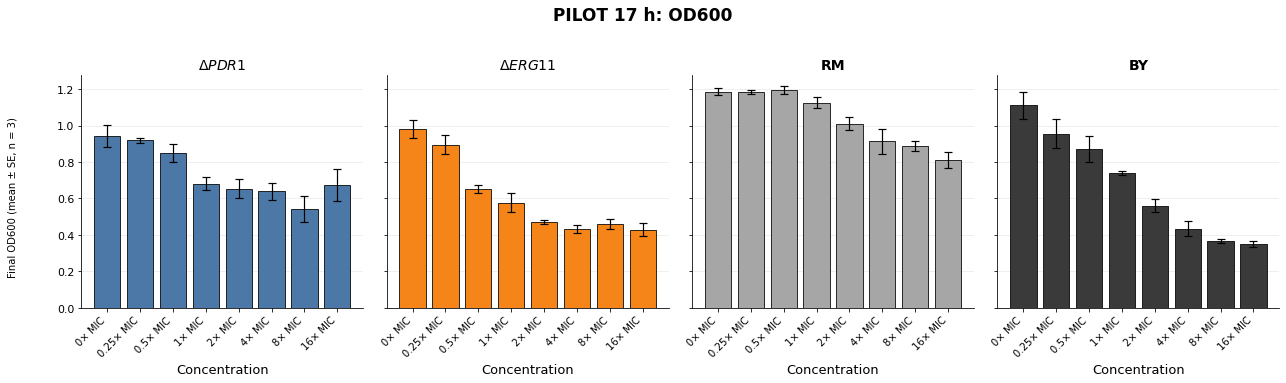

/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/PILOT_17H_outputs/OD600_figures/PILOT_17H_OD600_strainwise_1x4.png
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/PILOT_17H_outputs/OD600_figures/PILOT_17H_OD600_strainwise_1x4.pdf


In [7]:
od_paths = plot_od600_strainwise(
    summary_df=OD_SUMMARY,
    output_dir=OD_OUTDIR
)

print(*od_paths, sep="\n")

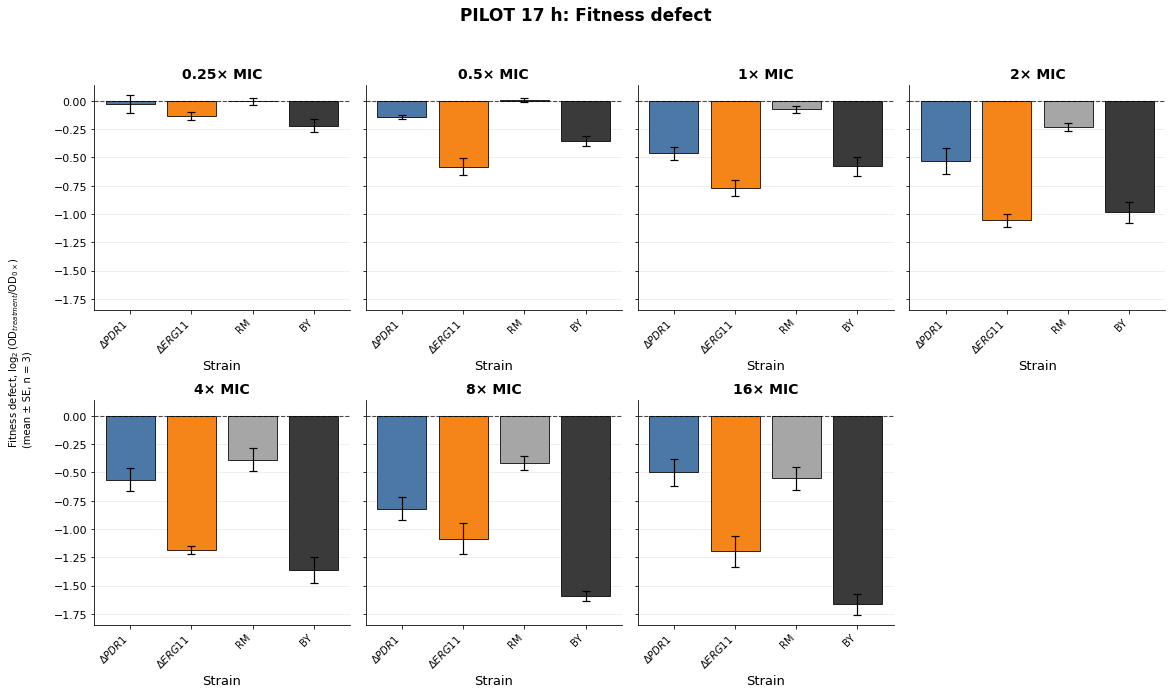

/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/PILOT_17H_outputs/FD_figures/PILOT_17H_Fitness_defect_2x4.png
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/PILOT_17H_outputs/FD_figures/PILOT_17H_Fitness_defect_2x4.pdf


In [8]:
FD_CONCENTRATIONS = [
    dose for dose in CONCENTRATION_ORDER
    if dose != 0
]

fd_paths = plot_fd_dosewise(
    summary_df=FD_SUMMARY,
    doses=FD_CONCENTRATIONS,
    output_dir=FD_OUTDIR
)

print(*fd_paths, sep="\n")

In [ ]:
data_with_fd.to_csv(
    SUMMARY_OUTDIR
    / "PILOT_17H_replicate_level_OD600_and_FD.csv",
    index=False
)

display(data_with_fd)